In [3]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
from optimization import *

In [4]:
n_trade = 250
seed = 100
n_scenarios = 10000

n_steps = 10
mcmc_results_dir = "/nfs/home/dannis/AC-model/TIM/TIM_MCMC_Results" 
mcmc_timestamp = "20250825"
trace_file = f'trace_{n_trade}_gap_100_seed_{seed}.nc'
posterior_samples, noise = sample_posteriors(f'{mcmc_results_dir}/{mcmc_timestamp}/{trace_file}', n_scenarios, n_steps)


Processing trace file: /nfs/home/dannis/AC-model/TIM/TIM_MCMC_Results/20250825/trace_250_gap_100_seed_100.nc
Mean of Kappa: 0.0011780074661376218, STD: 0.0004773140651808588
Mean of Gamma: 0.000932927289222641, STD: 0.0004830044267464594
Mean of rho: 7.416195634814161, STD: 1.863873085700884


In [44]:
def IS_tim_particles_num(action, posterior_samples, noise, n_scenarios, n_data, total_qty, tau, eta, sigma, spread):
    IS_exprs = []
    for p in range(n_scenarios):
        kappa = posterior_samples["kappa"][p]
        gamma = posterior_samples["gamma"][p]
        rho = 2.231  # Or posterior_samples["rho"][p]
        permanent_impact = 0.5 * gamma * total_qty**2 - 0.5 * gamma * np.sum(action**2)
        spread_cost = spread * total_qty
        temporary_impact = eta * np.sum(action**2)
        stochastic_term = 0.0
        for k in range(n_data + 1):
            inventory_expr_k = total_qty - np.sum(action[:k+1])
            stochastic_term += inventory_expr_k * noise[p, k]
        stochastic_term = sigma * math.sqrt(tau) * stochastic_term
     
        
        # Simplified transient impact calculation
        decay_factors = np.exp(-rho * tau * np.arange(n_data + 1))
        transient_impact = kappa * np.sum([
            action[k] * np.sum(action[:k] * decay_factors[k::-1][:k]) 
            for k in range(1, n_data + 1)
        ])
        
        IS_p = permanent_impact + spread_cost + temporary_impact - stochastic_term + transient_impact
        IS_exprs.append(IS_p)
    return np.array(IS_exprs)

In [72]:
total_qty = 1e5
T = 1
n_steps = 10
tau = T / n_steps
spread = 0
q = 5_00
eta = 1 / (q * 2)
sigma = 0.45


0.7366127115939658


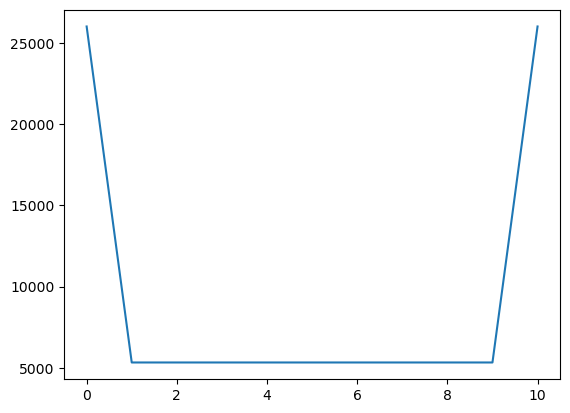

In [76]:
action = np.zeros(n_steps + 1)
action[0] = total_qty
# action = np.ones(n_steps + 1) * (total_qty / (n_steps + 1))
action[0] = 26000
action[-1] = 26000
action[1:-1] = (total_qty - action[0] - action[-1]) / (n_steps - 1)
assert np.isclose(np.sum(action), total_qty)
IS_exprs = IS_tim_particles_num(action, posterior_samples, noise, n_scenarios, n_steps, total_qty, tau, eta, sigma, spread)
plt.plot(action)
print(np.mean(IS_exprs / (eta * (total_qty**2 / T))))

0.7654022219721794


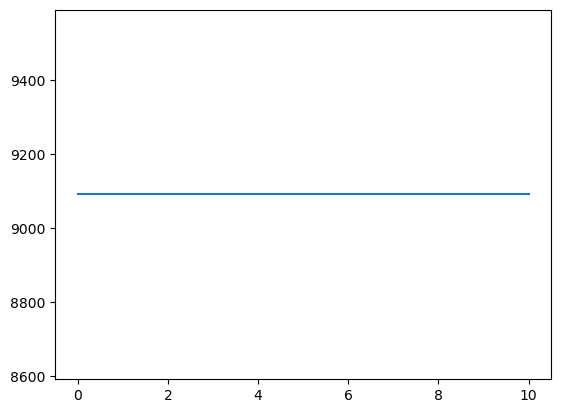

In [77]:

action = np.ones(n_steps + 1) * (total_qty / (n_steps + 1))

assert np.isclose(np.sum(action), total_qty)
IS_exprs = IS_tim_particles_num(action, posterior_samples, noise, n_scenarios, n_steps, total_qty, tau, eta, sigma, spread)
plt.plot(action)
print(np.mean(IS_exprs / (eta * (total_qty**2 / T))))

1.0


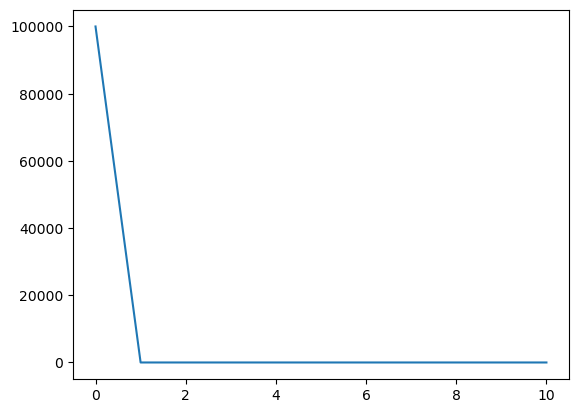

In [67]:
action = np.zeros(n_steps + 1)
action[0] = total_qty
assert np.isclose(np.sum(action), total_qty)
IS_exprs = IS_tim_particles_num(action, posterior_samples, noise, n_scenarios, n_steps, total_qty, tau, eta, sigma, spread)
plt.plot(action)
print(np.mean(IS_exprs / (eta * (total_qty**2 / T))))

In [ ]:
np.quantile(IS_exprs, 0.9)

np.float64(1018168.8024784538)